<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week7/Day1/Exercises_XP_W7_D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

**As stated in the instructions**  
- What is the key difference between traditional machine learning and deep learning?  
- How do artificial neural networks mimic the human brain?  
- Why does deep learning perform better on large datasets compared to traditional machine learning?  
- What are some challenges of deep learning, and how can they be addressed?  
- What is feature engineering, and why is it not needed in deep learning?  
- What role do hidden layers play in a deep learning model?  
- In an artificial neural network, what is the function of an activation function?

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.




***1. Key difference between traditional machine learning and deep learning***

Traditional machine learning relies on manually designed features, while deep learning automatically learns features from raw data using neural networks.
Example: In image classification, traditional ML requires edge detectors, while deep learning learns features directly from pixels.

***2. How artificial neural networks mimic the human brain***

Artificial neural networks mimic the brain by using interconnected neurons that process and transmit signals through weighted connections.

***3. Why deep learning performs better on large datasets***

Deep learning models improve with more data because they can learn complex patterns and representations that simpler models cannot capture.
Example: A deep model trained on millions of images can recognize subtle patterns like facial expressions better than a small model.

***4. Challenges of deep learning and how to address them***

Deep learning requires large datasets, high computational power, and can overfit. These can be addressed using techniques like data augmentation, regularization, and GPUs.

***5. What is feature engineering and why it is not needed in deep learning***

Feature engineering is the manual creation of input features. Deep learning eliminates this need because neural networks automatically learn useful features during training.

***6. Role of hidden layers***

Hidden layers transform input data into more abstract representations, enabling the network to learn complex relationships.

***7. Function of an activation function***

An activation function introduces non-linearity, allowing the network to model complex patterns instead of just linear relationships.

## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [2]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [3]:
# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)

y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})


{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


***Interpretation***
The perceptron suggests going outside in both cases. In both scenarios, the weighted sum exceeds the threshold of 20, so the output is 1. The bias increases the overall score, making it easier to pass the threshold, while temperature has a strong influence due to its higher weight

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [4]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [5]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train)
y_test_oh  = to_categorical(y_test)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


In [6]:
# To-Do:  Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

In [8]:
# To-Do: train then evaluate
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=32)
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9261 - loss: 0.2589
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9665 - loss: 0.1124
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9771 - loss: 0.0762
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9827 - loss: 0.0572
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9864 - loss: 0.0443
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0708
{'test_loss': 0.07081744074821472, 'test_acc': 0.9778000116348267}


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [9]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# To-Do: compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
y = max(0,z) #Hint: ReLU acts like max functions and leaves only positive outputs

print({"z": z, "prediction": y})


{'z': 51002.1, 'prediction': 51002.1}


***Interpretation***

The predicted house price is approximately 51,002. The bias dominates the prediction, acting as a base price. The input features contribute relatively small adjustments. Since the result is positive, ReLU does not change it. If inputs were scaled differently, their influence would increase significantly.


## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [11]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


***Explanation***

Gradient descent reduces error by adjusting weights in the direction that minimizes the loss function. The gradients indicate how much each parameter contributes to the error, so updating them reduces the difference between predicted and true values.

***Effect of Learning Rate***

Small learning rate → slow learning but stable
Large learning rate → faster learning but may overshoot or diverge

Example: Increasing the learning rate to 0.1 may cause unstable updates, while reducing it to 0.001 slows convergence.

## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


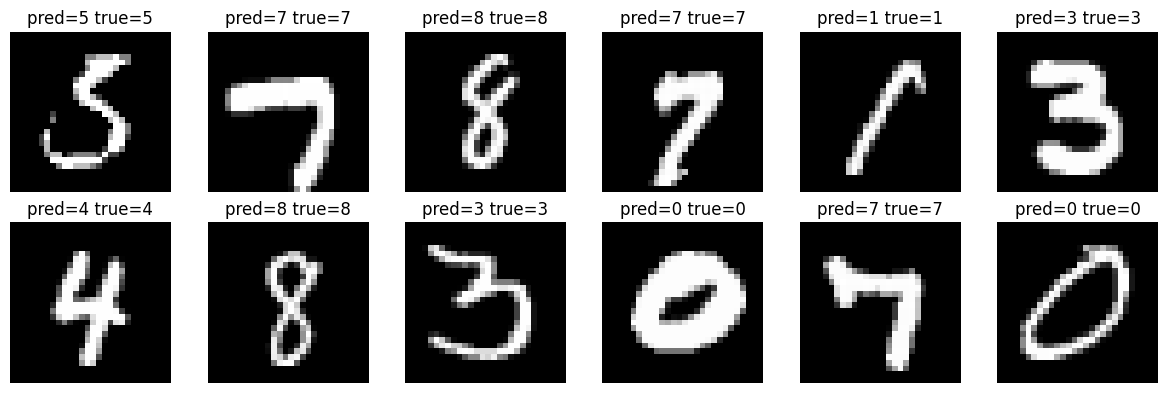

In [13]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
# To-Do: select N samples from x_test by using np.random.choice
idx = np.random.choice(len(x_test), size=12, replace=False)
x_vis = x_test[idx]
y_true = y_test[idx]

# To-Do: get predictions
y_prob = model.predict(x_vis)
y_pred = np.argmax(y_prob, axis=1)

#plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}" )
    plt.axis("off")
plt.tight_layout()
plt.show()
